In [8]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [9]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:05<00:00, 4.45MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 102kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.10MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


In [7]:
pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.1 MB 223.7 kB/s eta 0:00:16
   ----- ---------------------------------- 0.5/4.1 MB 223.7 kB/s eta 0:00:16
   ----- ---------------------------------- 0.5/4.1 MB 223.7 kB/s eta 0:00:16
   ----- ---------------------------------- 0.5/4.1 MB 223.7 kB/s eta 0:00:16
   ------- -------------------------------- 0.8/4.1 MB 270

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.


In [10]:
pip install torchvision -v

Using pip 24.2 from C:\ProgramData\anaconda3\Lib\site-packages\pip (python 3.12)
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [15]:
len(training_data)

60000

In [25]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor
)

In [27]:
len(test_data)


10000

In [51]:
image, label = training_data[1]

In [53]:
image.shape

torch.Size([1, 28, 28])

In [55]:
image.squeeze().shape

torch.Size([28, 28])

In [57]:
label

0

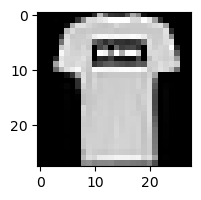

In [60]:
plt.figure(figsize=(2,2))
plt.imshow(image.squeeze(), cmap="gray")

In [64]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

labels_map[label]

'Coat'

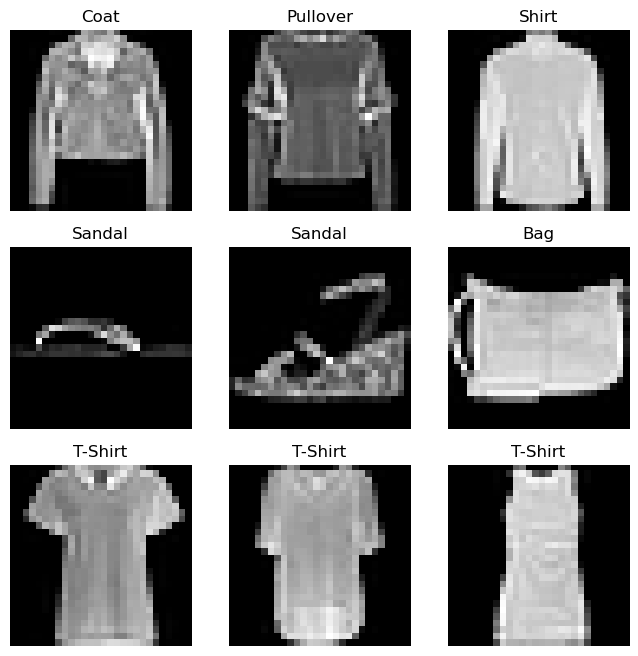

In [66]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [68]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

In [72]:
for images, labels in train_dataloader:
    print(images.size())
    break

torch.Size([64, 1, 28, 28])


In [74]:
data_iter = iter(train_dataloader)
images, labels = next(data_iter)

In [78]:
img = images[2].squeeze()
label = labels[2]

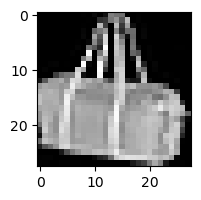

In [80]:
plt.figure(figsize=(2,2))
plt.imshow(img, cmap="gray")
plt.show()

In [82]:
labels_map[label.item()]

'Bag'